In [1]:
import numpy as np
import pandas as pd

In [8]:
import os
base_path = r"d:\NEU\Time-series Analysis\Steam Sales Window"
data = pd.read_csv(os.path.join(base_path, 'data/raw/TS_price_history.csv'), on_bad_lines='skip')
game_info = pd.read_csv(os.path.join(base_path, 'data/raw/TS_game_info.csv'), on_bad_lines='skip')

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")

<span style = "font-family: Verdana; font-size: 20px">

### **Dataset Overview**

In [18]:
print("=" * 80)
print("PRICE HISTORY DATASET")
print("=" * 80)
print(f"\nShape: {data.shape}")
print(f"\nData Types:\n{data.dtypes}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nDataset Info:")
data.info()

PRICE HISTORY DATASET

Shape: (267593, 10)

Data Types:
app_id               float64
game_title            object
date                  object
price                float64
regular_price        float64
sales_percentage     float64
shop_id                int64
shop_name             object
currency              object
is_historical_low       bool
dtype: object

First few rows:
     app_id                game_title        date  price  regular_price  \
0  752590.0  A Plague Tale: Innocence  2019-01-31  39.14          44.99   
1  752590.0  A Plague Tale: Innocence  2019-01-31  44.99          44.99   
2  752590.0  A Plague Tale: Innocence  2019-01-31  44.64          52.52   
3  752590.0  A Plague Tale: Innocence  2019-01-31  43.51          51.53   
4  752590.0  A Plague Tale: Innocence  2019-01-31  43.51          51.53   

   sales_percentage  shop_id       shop_name currency  is_historical_low  
0              13.0        6       Fanatical      USD              False  
1               0.0   

In [10]:
print("\n" + "=" * 80)
print("GAME INFO DATASET")
print("=" * 80)
print(f"\nShape: {game_info.shape}")
print(f"\nData Types:\n{game_info.dtypes}")
print(f"\nFirst few rows:")
print(game_info.head())
print(f"\nDataset Info:")
game_info.info()


GAME INFO DATASET

Shape: (226, 13)

Data Types:
app_id                 float64
game_title              object
mature                    bool
early_access              bool
release_date            object
tags                    object
history_rows             int64
latest_prices_rows       int64
status                  object
error                  float64
first_price_record      object
latest_price_record     object
historical_low         float64
dtype: object

First few rows:
      app_id                        game_title  mature  early_access  \
0   752590.0          A Plague Tale: Innocence   False         False   
1  1182900.0            A Plague Tale: Requiem   False         False   
2   384190.0                              ABZU   False         False   
3   813230.0                       ANIMAL WELL   False         False   
4  1888160.0  ARMORED CORE VI FIRES OF RUBICON   False         False   

  release_date                                               tags  \
0   2019-05-14

<span style = "font-family: Verdana; font-size: 20px">

### **Missing Values Analysis**

In [11]:
print("Price History - Missing Values:")
missing_price = data.isnull().sum()
print(missing_price[missing_price > 0] if (missing_price > 0).any() else "No missing values")
print(f"Percentage: {(data.isnull().sum() / len(data) * 100).round(2)}")

print("\nGame Info - Missing Values:")
missing_game = game_info.isnull().sum()
print(missing_game[missing_game > 0] if (missing_game > 0).any() else "No missing values")
print(f"Percentage: {(game_info.isnull().sum() / len(game_info) * 100).round(2)}")

Price History - Missing Values:
app_id    4306
dtype: int64
Percentage: app_id               1.61
game_title           0.00
date                 0.00
price                0.00
regular_price        0.00
sales_percentage     0.00
shop_id              0.00
shop_name            0.00
currency             0.00
is_historical_low    0.00
dtype: float64

Game Info - Missing Values:
app_id                   3
release_date             1
tags                     3
error                  226
first_price_record       2
latest_price_record      2
historical_low           2
dtype: int64
Percentage: app_id                   1.33
game_title               0.00
mature                   0.00
early_access             0.00
release_date             0.44
tags                     1.33
history_rows             0.00
latest_prices_rows       0.00
status                   0.00
error                  100.00
first_price_record       0.88
latest_price_record      0.88
historical_low           0.88
dtype: float64


<span style = "font-family: Verdana; font-size: 20px">

### **Unique Value**

In [33]:
print("=" * 80)
print("PRICE HISTORY DATASET - UNIQUE VALUE ANALYSIS")
print("=" * 80)

unique_summary = pd.DataFrame({
    "unique_non_null": data.nunique(dropna=True),
    "unique_including_nan": data.nunique(dropna=False),
    "missing_count": data.isna().sum()
}).sort_values("unique_including_nan", ascending=False)

print(unique_summary)

print("\nColumns with low cardinality (<= 20 unique values):")
low_card_cols = unique_summary[unique_summary["unique_including_nan"] <= 20].index.tolist()
for col in low_card_cols:
    print(f"\n{col} ({unique_summary.loc[col, 'unique_including_nan']} unique):")
    print(sorted(data[col].dropna().unique().tolist())[:20])

PRICE HISTORY DATASET - UNIQUE VALUE ANALYSIS
                   unique_non_null  unique_including_nan  missing_count
price                         5697                  5697              0
regular_price                 5215                  5215              0
date                          4857                  4857              0
game_title                     217                   217              0
app_id                         214                   215           4298
sales_percentage                98                    98              0
shop_id                         59                    59              0
shop_name                       59                    59              0
currency                         3                     3              0
is_historical_low                2                     2              0

Columns with low cardinality (<= 20 unique values):

currency (3 unique):
['EUR', 'GBP', 'USD']

is_historical_low (2 unique):
[False, True]


<span style = "font-family: Verdana; font-size: 20px">

### **Statistical Summary**

In [12]:
print("Price History - Statistical Summary:")
print(data.describe())

print("\n\nGame Info - Statistical Summary:")
print(game_info.describe())

Price History - Statistical Summary:
             app_id          price  regular_price  sales_percentage  \
count  2.638770e+05  268183.000000  268183.000000     268183.000000   
mean   6.338552e+05      24.056549      34.423860         31.430411   
std    5.504907e+05     334.573804     334.549895         31.485699   
min    2.400000e+02       0.000000       0.000000          0.000000   
25%    2.557100e+05       9.990000      19.990000          0.000000   
50%    3.915400e+05      19.990000      29.990000         18.000000   
75%    8.121400e+05      29.990000      44.990000         64.000000   
max    3.321460e+06  100000.000000  100000.000000        100.000000   

             shop_id  
count  268183.000000  
mean       33.958349  
std        19.577436  
min         2.000000  
25%        20.000000  
50%        29.000000  
75%        49.000000  
max        76.000000  


Game Info - Statistical Summary:
             app_id  history_rows  latest_prices_rows  error  historical_low
coun

<span style = "font-family: Verdana; font-size: 20px">

### **Distribution Analysis - Price History**

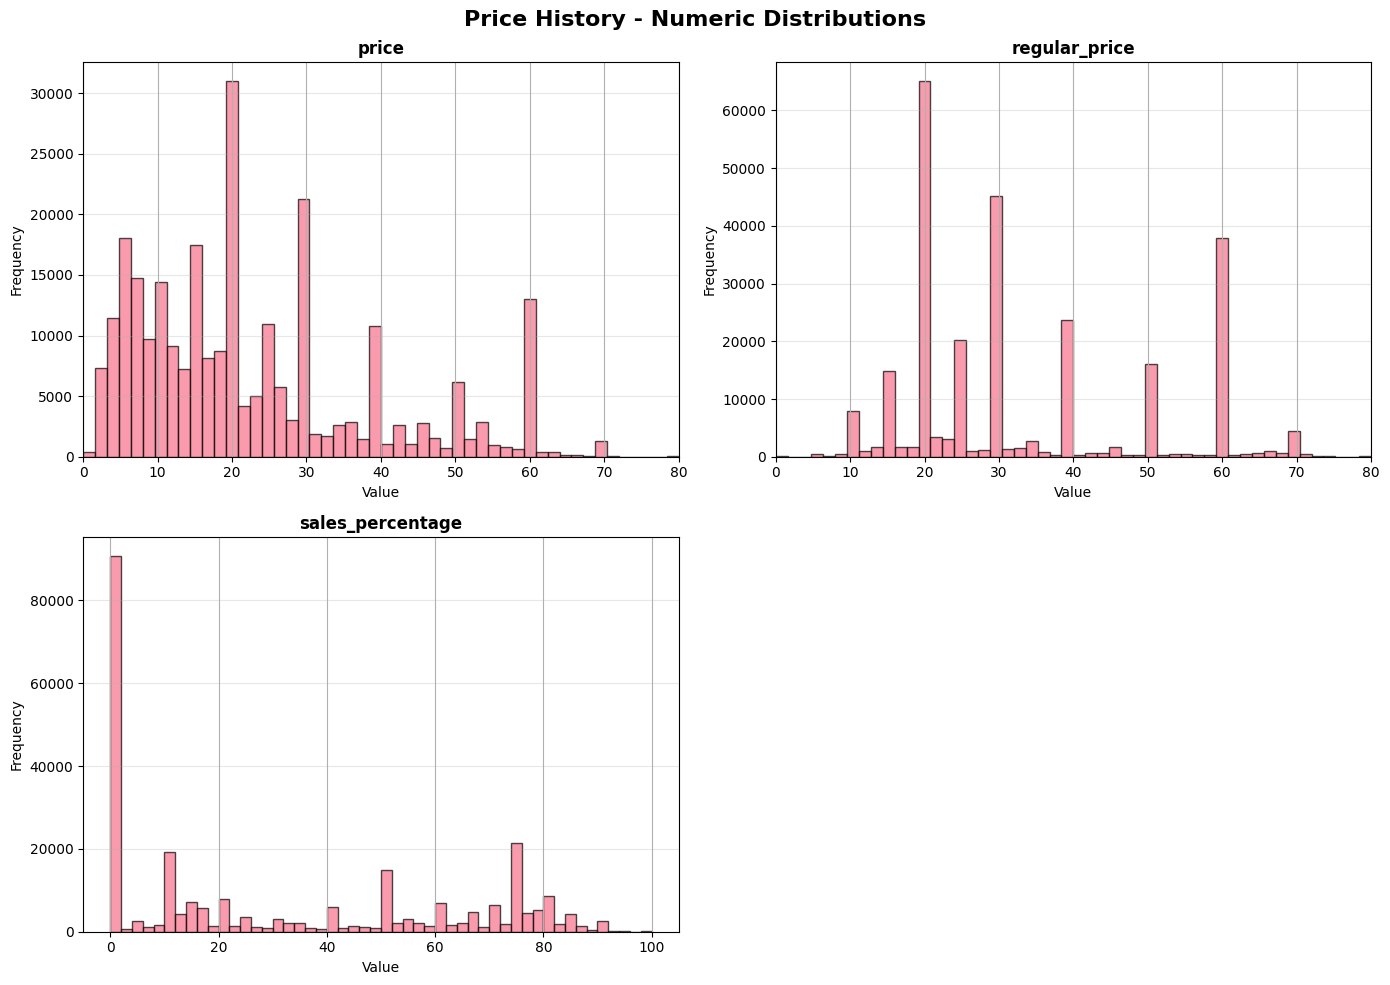

Numeric columns: ['price', 'regular_price', 'sales_percentage']


In [32]:
# Get numeric columns from price history, excluding ID-like columns
numeric_cols_price = data.select_dtypes(include=[np.number]).columns.drop(['app_id', 'shop_id'], errors='ignore')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Price History - Numeric Distributions', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, col in enumerate(numeric_cols_price[:4]):
    ax = axes[idx]
    data[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)
    
    if col in ['price', 'regular_price']:
        ax.set_xlim(0, 80)

# remove unused subplot(s)
for ax in axes[len(numeric_cols_price[:4]):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

print(f"Numeric columns: {list(numeric_cols_price)}")


<span style = "font-family: Verdana; font-size: 20px">

### **Distribution Analysis - Game Info**

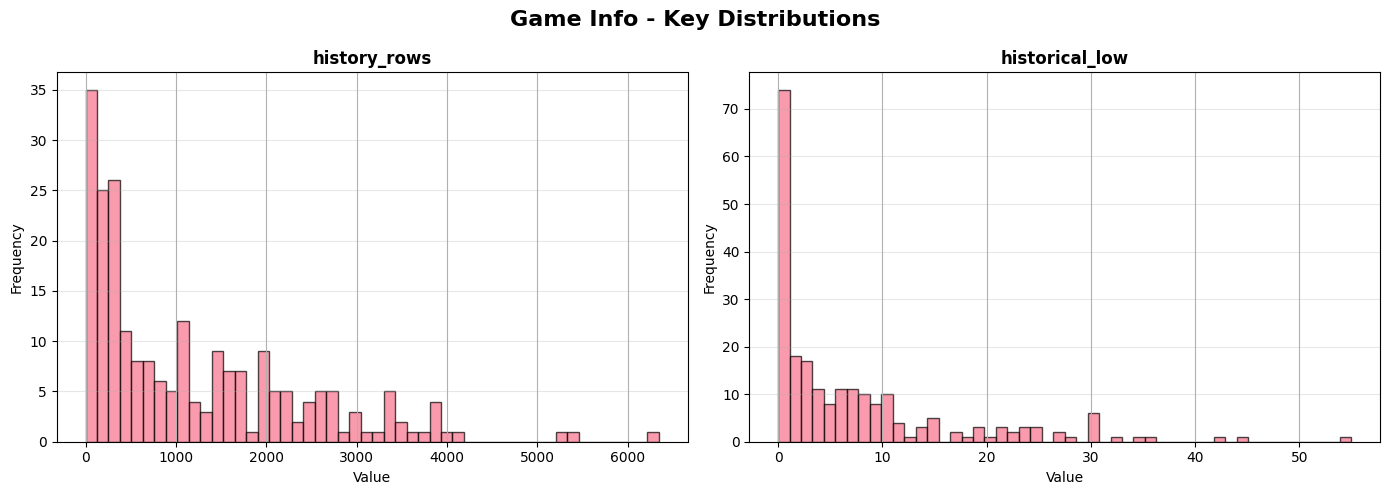

Analyzed columns: ['history_rows', 'historical_low']


In [29]:
# Get numeric columns from game info
numeric_cols_game = game_info.select_dtypes(include=[np.number]).columns

# Filter to only history_rows and historical_low
cols_to_plot = ['history_rows', 'historical_low']
cols_to_plot = [col for col in cols_to_plot if col in numeric_cols_game]

if len(cols_to_plot) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Game Info - Key Distributions', fontsize=16, fontweight='bold')
    
    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        game_info[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Analyzed columns: {cols_to_plot}")
else:
    print("Specified columns not found in Game Info dataset")

<span style = "font-family: Verdana; font-size: 20px">

### **Correlation Analysis** 

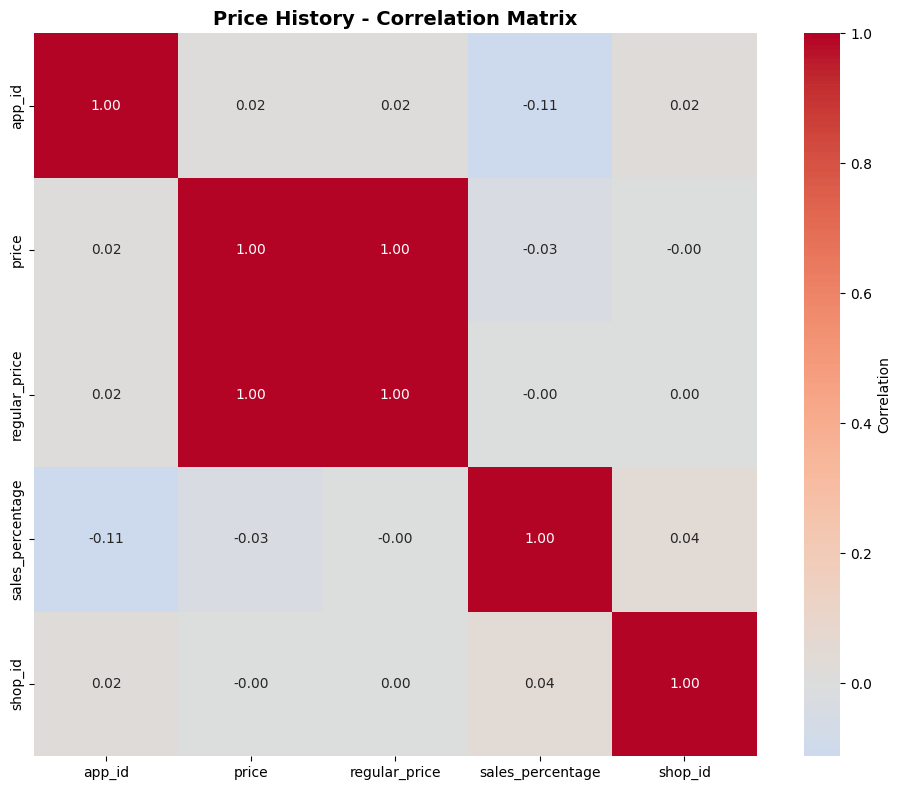

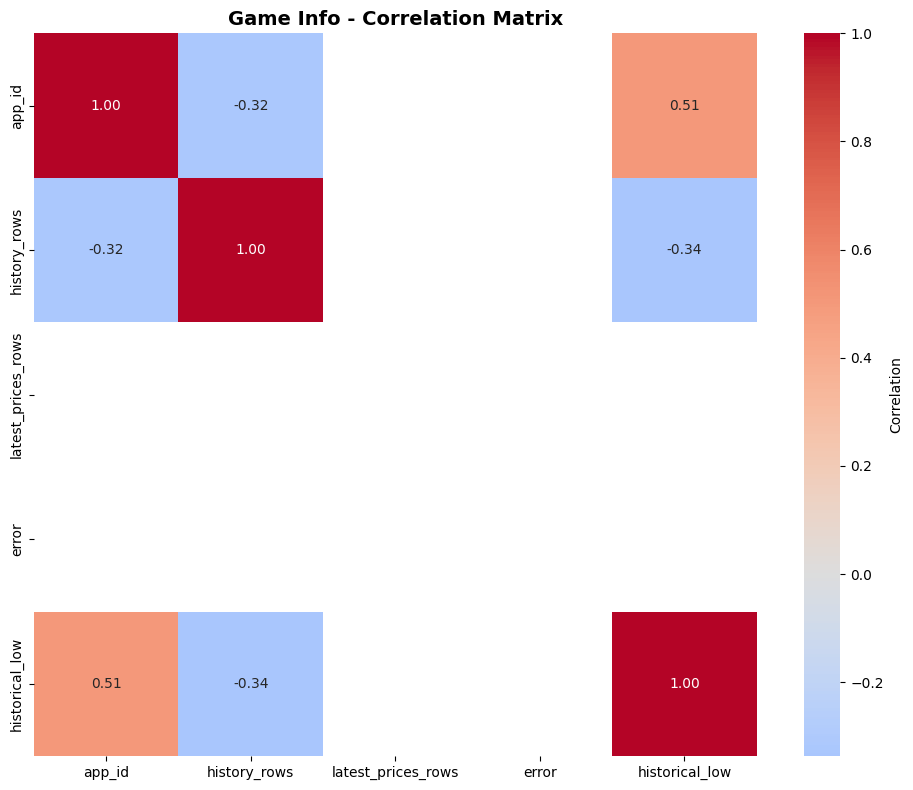

In [15]:
# Price History Correlation
if len(numeric_cols_price) > 1:
    corr_price = data[numeric_cols_price].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_price, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Price History - Correlation Matrix', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

# Game Info Correlation
if len(numeric_cols_game) > 1:
    corr_game = game_info[numeric_cols_game].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_game, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Game Info - Correlation Matrix', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

<span style = "font-family: Verdana; font-size: 20px">

### **Key Insights & Summary**

In [19]:
print("\n" + "=" * 80)
print("SUMMARY OF KEY FINDINGS")
print("=" * 80)

print("\nPrice History Dataset:")
print(f"  • Total records: {len(data):,}")
print(f"  • Total features: {len(data.columns)}")
print(f"  • Date range: Need to check for temporal columns")
print(f"  • Numeric columns: {len(numeric_cols_price)}")
print(f"  • Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nGame Info Dataset:")
print(f"  • Total games: {len(game_info):,}")
print(f"  • Total features: {len(game_info.columns)}")
print(f"  • Numeric columns: {len(numeric_cols_game)}")
print(f"  • Memory usage: {game_info.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nData Quality:")
print(f"  • Price history duplicates: {data.duplicated().sum()}")
print(f"  • Game info duplicates: {game_info.duplicated().sum()}")

print("\n" + "=" * 80)


SUMMARY OF KEY FINDINGS

Price History Dataset:
  • Total records: 267,593
  • Total features: 10
  • Date range: Need to check for temporal columns
  • Numeric columns: 5
  • Memory usage: 74.18 MB

Game Info Dataset:
  • Total games: 226
  • Total features: 13
  • Numeric columns: 5
  • Memory usage: 0.10 MB

Data Quality:
  • Price history duplicates: 11858
  • Game info duplicates: 6

